In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('sentiment_analysis.csv')

In [3]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [4]:
data[data['label']==0]

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
6,7,0,Happy for us .. #instapic #instadaily #us #son...
...,...,...,...
7915,7916,0,Live out loud #lol #liveoutloud #selfie #smile...
7916,7917,0,We would like to wish you an amazing day! Make...
7917,7918,0,Helping my lovely 90 year old neighbor with he...
7918,7919,0,Finally got my #smart #pocket #wifi stay conne...


In [5]:
data[data['label']==1]

,id,label,tweet
4,5,1,What amazing service! Apple won't even talk to...
5,6,1,iPhone software update fucked up my phone big ...
10,11,1,hey #apple when you make a new ipod dont make ...
11,12,1,Ha! Not heavy machinery but it does what I nee...
12,13,1,Contemplating giving in to the iPhone bandwago...
...,...,...,...
7901,7902,1,@brendan_brady1: The new apple advert can fuck...
7902,7903,1,All I wanna do is put music from my iTunes on ...
7904,7905,1,#FuckYou #Apple one thing stops working and I ...
7908,7909,1,SECOND FUCKING TIME. Stay on hold for 30 mins ...


In [6]:
# 1 for positive 
# 0 for nagative 

In [7]:
df=data[['tweet','label']].copy()

In [8]:
# checking for null values
df.isnull().sum()

tweet    0
label    0
dtype: int64

In [9]:
#checking for duplicated values
df.duplicated().sum()

2

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df

,tweet,label
0,#fingerprint #Pregnancy Test https://goo.gl/h1...,0
1,Finally a transparant silicon case ^^ Thanks t...,0
2,We love this! Would you go? #talk #makememorie...,0
3,I'm wired I know I'm George I was made that wa...,0
4,What amazing service! Apple won't even talk to...,1
...,...,...
7915,Live out loud #lol #liveoutloud #selfie #smile...,0
7916,We would like to wish you an amazing day! Make...,0
7917,Helping my lovely 90 year old neighbor with he...,0
7918,Finally got my #smart #pocket #wifi stay conne...,0


In [14]:
p=df['label'].value_counts()

In [15]:
p

label
0    5892
1    2026
Name: count, dtype: int64

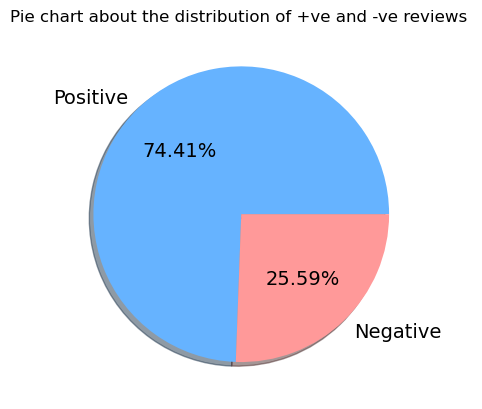

In [43]:
#visualizing negative and positive tweets
plt.title('Pie chart about the distribution of +ve and -ve reviews ')
plt.pie(p,labels=['Positive','Negative'],autopct='%0.2f%%',shadow=True,colors=['#66b3ff','#ff9999'],textprops={'fontsize':14,'color':'black'})
plt.show()

In [44]:
# it is imbalanced data

In [45]:
# now see is there any connection between the text length , word length and sentence length to the target variable(label)

In [46]:
# now e add text_length , word_length, sent_length columns

In [48]:
df['text_length']=df['tweet'].apply(len)

In [49]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\srinu
[nltk_data]     barnikala\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [53]:
def word_tokenize(text):
    y=nltk.word_tokenize(text)
    return len(y)

In [63]:
df['word_length']=df['tweet'].apply(word_tokenize)

In [59]:
def sent_tokenize(text):
    y=nltk.sent_tokenize(text)
    return len(y)

In [64]:
df['sent_length']=df['tweet'].apply(sent_tokenize)

In [65]:
df

,tweet,label,text_length,word_length,sent_length
0,#fingerprint #Pregnancy Test https://goo.gl/h1...,0,128,26,1
1,Finally a transparant silicon case ^^ Thanks t...,0,131,25,1
2,We love this! Would you go? #talk #makememorie...,0,123,28,3
3,I'm wired I know I'm George I was made that wa...,0,112,26,1
4,What amazing service! Apple won't even talk to...,1,124,27,2
...,...,...,...,...,...
7915,Live out loud #lol #liveoutloud #selfie #smile...,0,107,20,1
7916,We would like to wish you an amazing day! Make...,0,134,32,2
7917,Helping my lovely 90 year old neighbor with he...,0,129,29,1
7918,Finally got my #smart #pocket #wifi stay conne...,0,133,28,2


In [66]:
# now we perform some EDA



In [70]:
df.drop(columns='tweet')[df['label']==1].describe()

,label,text_length,word_length,sent_length
count,2026.0,2026.000000,2026.000000,2026.000000
mean,1.0,104.830701,23.160415,1.938796
std,0.0,29.888029,6.598947,1.005273
min,1.0,43.000000,11.000000,1.000000
25%,1.0,84.000000,18.000000,1.000000
50%,1.0,106.000000,23.000000,2.000000
75%,1.0,124.000000,27.000000,2.000000
max,1.0,330.000000,68.000000,8.000000


In [71]:
df.drop(columns='tweet')[df['label']==0].describe()

,label,text_length,word_length,sent_length
count,5892.0,5892.000000,5892.000000,5892.000000
mean,0.0,137.162424,27.427699,1.670231
std,0.0,51.118648,9.503354,1.108773
min,0.0,7.000000,3.000000,1.000000
25%,0.0,114.000000,22.000000,1.000000
50%,0.0,126.000000,25.000000,1.000000
75%,0.0,133.000000,29.000000,2.000000
max,0.0,398.000000,75.000000,20.000000


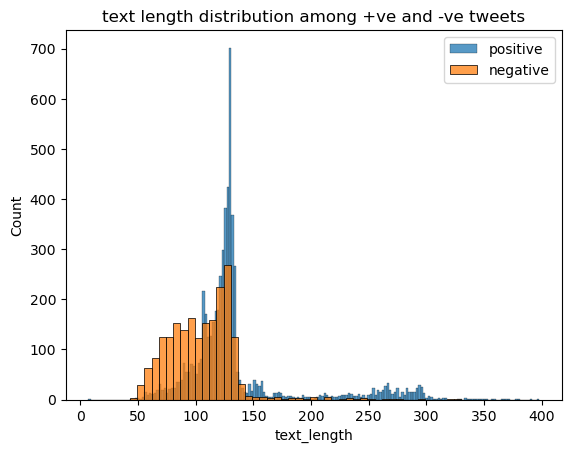

In [76]:
plt.title('text length distribution among +ve and -ve tweets')
sns.histplot(df[df['label']==0]['text_length'],label='positive')
sns.histplot(df[df['label']==1]['text_length'],label='negative')
plt.legend()

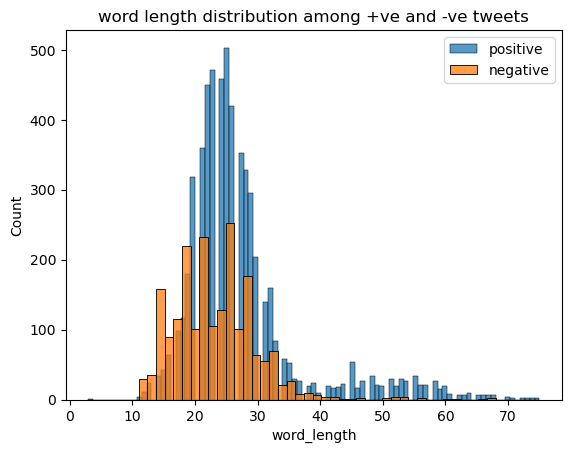

In [77]:
plt.title('word length distribution among +ve and -ve tweets')
sns.histplot(df[df['label']==0]['word_length'],label='positive')
sns.histplot(df[df['label']==1]['word_length'],label='negative')
plt.legend()

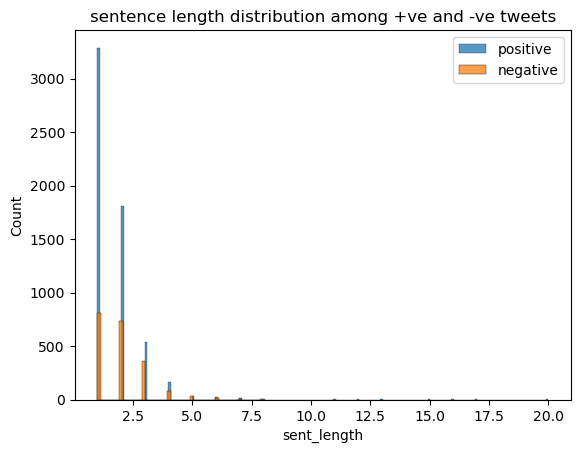

In [78]:
plt.title('sentence length distribution among +ve and -ve tweets')
sns.histplot(df[df['label']==0]['sent_length'],label='positive')
sns.histplot(df[df['label']==1]['sent_length'],label='negative')
plt.legend()

In [79]:
df.drop(columns='tweet').corr()

,label,text_length,word_length,sent_length
label,1.000000,-0.289694,-0.205881,0.107569
text_length,-0.289694,1.000000,0.872454,0.135367
word_length,-0.205881,0.872454,1.000000,0.240210
sent_length,0.107569,0.135367,0.240210,1.000000


In [82]:
# text preprocessing
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
po=PorterStemmer()

In [87]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [86]:
stopwords.words('english')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [88]:
po.stem('changing')

'chang'

In [89]:
po.stem('dancing')

'danc'

In [92]:
str='srinu@srinu'
str.isalnum()
# because it have a special character

False

In [91]:
po.stem('killed')

'kill'

In [83]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in string.punctuation and i not in stopwords.words('english'):
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(po.stem(i))
    return ' '.join(y)    
            

In [84]:
df['tweet'].apply(transform_text)

0       fingerprint pregnanc test http android app bea...
1       final transpar silicon case thank uncl yay son...
2       love would go talk makememori unplug relax iph...
3       wire know georg made way iphon cute daventri h...
4       amaz servic appl wo even talk question unless ...
                              ...                        
7915    live loud lol liveoutloud selfi smile soni mus...
7916    would like wish amaz day make everi minut coun...
7917    help love 90 year old neighbor ipad morn made ...
7918    final got smart pocket wifi stay connect anyti...
7919    appl barcelona appl store bcn barcelona travel...
Name: tweet, Length: 7918, dtype: object

In [85]:
df['transformed_text']=df['tweet'].apply(transform_text)

In [94]:
df=df[['transformed_text','label']].copy()

In [95]:
df.head()

,transformed_text,label
0,fingerprint pregnanc test http android app bea...,0
1,final transpar silicon case thank uncl yay son...,0
2,love would go talk makememori unplug relax iph...,0
3,wire know georg made way iphon cute daventri h...,0
4,amaz servic appl wo even talk question unless ...,1


In [96]:
import wordcloud
from wordcloud import WordCloud

In [102]:
wc=WordCloud(max_words=50,background_color='white')

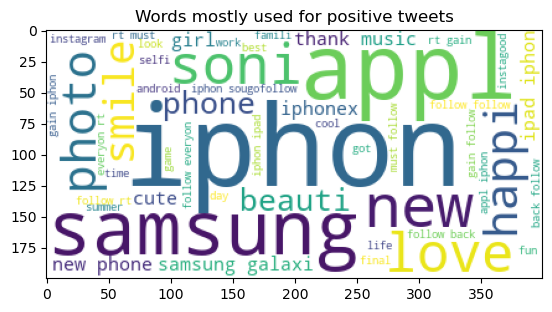

In [103]:
plt.title('Words mostly used for positive tweets')
plt.imshow(wc.generate(df[df['label']==0]['transformed_text'].str.cat(sep=' ')))

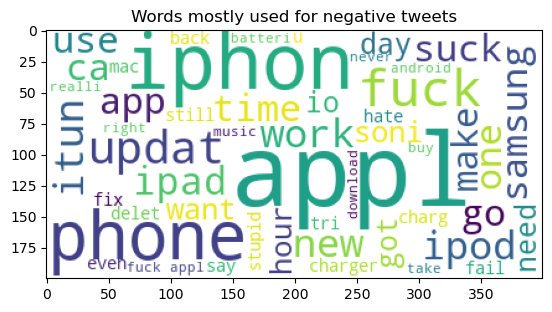

In [104]:
plt.title('Words mostly used for negative tweets')
plt.imshow(wc.generate(df[df['label']==1]['transformed_text'].str.cat(sep=' ')))

In [143]:
neg_words=[]
unq_neg=[]
pos_words=[]
unq_pos=[]

In [144]:
for i in df[df['label']==0]['transformed_text']:
    for k in i.split(' '):
        pos_words.append(k)
for j in df[df['label']==1]['transformed_text']:
    for k in j.split(' '):
        neg_words.append(k)

In [145]:
for i in pos_words:
    if i not in neg_words:
        unq_pos.append(i)

In [146]:
for i in neg_words:
    if i not in pos_words:
        unq_neg.append(i)

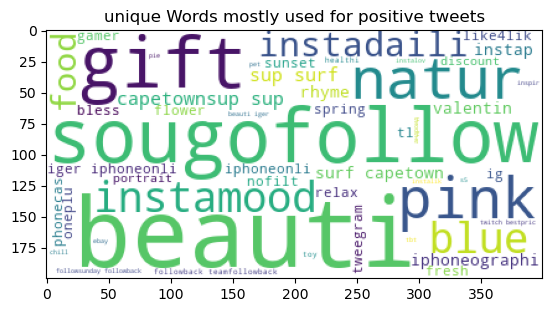

In [148]:
plt.title('unique Words mostly used for positive tweets')
plt.imshow(wc.generate(','.join(unq_pos)))

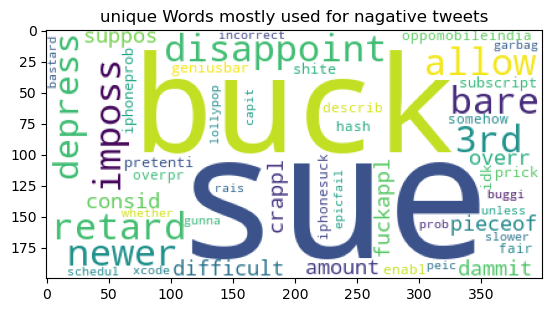

In [149]:
plt.title('unique Words mostly used for nagative tweets')
plt.imshow(wc.generate(','.join(unq_neg)))

In [150]:
from collections import Counter

In [156]:
Counter(unq_pos).most_common()[0:51]

[('beauti', 323),
 ('sougofollow', 165),
 ('gift', 164),
 ('iger', 142),
 ('iphoneonli', 131),
 ('natur', 107),
 ('instamood', 90),
 ('pink', 87),
 ('toy', 74),
 ('blue', 71),
 ('instadaili', 66),
 ('2018', 64),
 ('food', 64),
 ('tl', 62),
 ('rhyme', 62),
 ('sunset', 61),
 ('capetown', 58),
 ('ig', 57),
 ('instap', 55),
 ('flower', 55),
 ('followback', 55),
 ('surf', 55),
 ('gamer', 54),
 ('valentin', 53),
 ('capetownsup', 53),
 ('sup', 53),
 ('2017', 53),
 ('phonecas', 53),
 ('newyear', 51),
 ('iphoneographi', 51),
 ('tweegram', 50),
 ('twitch', 50),
 ('like4lik', 43),
 ('sonyphoto', 42),
 ('relax', 41),
 ('nofilt', 41),
 ('vsco', 41),
 ('discount', 41),
 ('photograph', 39),
 ('bestpric', 39),
 ('bless', 39),
 ('2016', 38),
 ('tbt', 38),
 ('spring', 34),
 ('fresh', 34),
 ('instago', 33),
 ('oneplu', 33),
 ('chill', 32),
 ('teamfollowback', 32),
 ('colleg', 32),
 ('iphonecas', 32)]

In [157]:
Counter(unq_neg).most_common()[0:51]

[('sue', 11),
 ('buck', 6),
 ('disappoint', 6),
 ('retard', 6),
 ('imposs', 6),
 ('allow', 6),
 ('newer', 6),
 ('bare', 6),
 ('3rd', 6),
 ('depress', 5),
 ('2000', 5),
 ('pieceof', 5),
 ('amount', 5),
 ('overr', 5),
 ('difficult', 5),
 ('suppos', 5),
 ('consid', 5),
 ('crappl', 5),
 ('fuckappl', 5),
 ('dammit', 5),
 ('geniusbar', 4),
 ('idk', 4),
 ('shite', 4),
 ('pretenti', 4),
 ('subscript', 4),
 ('iphoneprob', 4),
 ('prick', 4),
 ('oppomobileindia', 4),
 ('enabl', 4),
 ('overpr', 4),
 ('somehow', 4),
 ('fair', 4),
 ('hash', 4),
 ('describ', 4),
 ('iphonesuck', 4),
 ('unless', 3),
 ('gunna', 3),
 ('schedul', 3),
 ('buggi', 3),
 ('epicfail', 3),
 ('garbag', 3),
 ('whether', 3),
 ('peic', 3),
 ('bastard', 3),
 ('xcode', 3),
 ('there', 3),
 ('rais', 3),
 ('lollypop', 3),
 ('incorrect', 3),
 ('capit', 3),
 ('prob', 3)]

In [158]:
# now e have to vectorize the textual data
from sklearn.feature_extraction.text import CountVectorizer

In [159]:
cv=CountVectorizer()

In [163]:
x=cv.fit_transform(df['transformed_text']).toarray()

In [164]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [165]:
y=df['label']

In [167]:
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,StratifiedKFold

In [169]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

In [168]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [265]:
model=LogisticRegression(penalty='l2',solver='liblinear')

In [266]:
model.fit(x_train,y_train)

LogisticRegression(solver='liblinear')

In [267]:
y_pred=model.predict(x_test)

In [268]:
y_pred_train=model.predict(x_train)

accuracy score: 0.8737373737373737
precision score: 0.7549019607843137


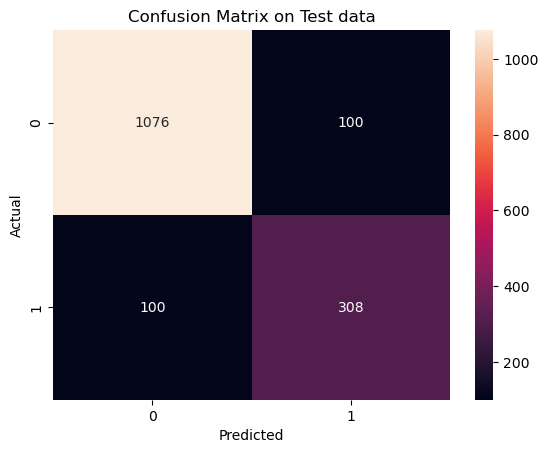

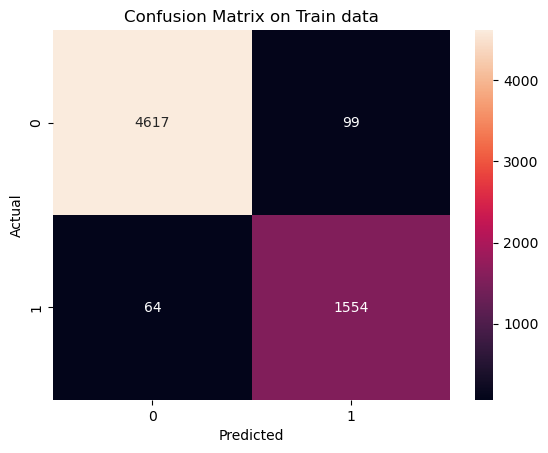

In [269]:
print('accuracy score:',accuracy_score(y_test,y_pred))
print('precision score:',precision_score(y_test,y_pred))
plt.title('Confusion Matrix on Test data')
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plt.title('Confusion Matrix on Train data')
sns.heatmap(confusion_matrix(y_train,y_pred_train),annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [311]:
import pickle

In [312]:
pickle.dump(cv,open('vectorizer.pkl','wb'))

In [313]:
pickle.dump(model,open('model.pkl','wb'))